In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [3]:
df.drop(["day","month","year"] , axis=1 , inplace=True)

In [4]:
df["Classes"] = df["Classes"].str.strip().map({
    "not fire" : 0,
    "fire" : 1})

In [5]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


In [9]:
X=df.drop("FWI" , axis=1)
y=df["FWI"]

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)

In [14]:
X_train.shape

(194, 11)

# Feature Selection

In [15]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.653725,-0.308149,-0.313112,0.690285,0.468911,0.372163,0.613138,0.446280,0.539642,0.258344
RH,-0.653725,1.000000,0.211645,0.239441,-0.649239,-0.401836,-0.220945,-0.714640,-0.346511,-0.454926,-0.408441
Ws,-0.308149,0.211645,1.000000,0.235922,-0.176596,0.004712,0.092866,-0.002300,0.037465,-0.075322,-0.202357
Rain,-0.313112,0.239441,0.235922,1.000000,-0.547864,-0.288538,-0.301110,-0.349903,-0.299179,-0.378585,-0.057382
FFMC,0.690285,-0.649239,-0.176596,-0.547864,1.000000,0.611978,0.519513,0.751819,0.598248,0.786012,0.254770
DMC,0.468911,-0.401836,0.004712,-0.288538,0.611978,1.000000,0.876122,0.679049,0.983891,0.606775,0.188980
DC,0.372163,-0.220945,0.092866,-0.301110,0.519513,0.876122,1.000000,0.512934,0.946181,0.538893,-0.083038
ISI,0.613138,-0.714640,-0.002300,-0.349903,0.751819,0.679049,0.512934,1.000000,0.637669,0.740072,0.291889
BUI,0.446280,-0.346511,0.037465,-0.299179,0.598248,0.983891,0.946181,0.637669,1.000000,0.602102,0.090326
Classes,0.539642,-0.454926,-0.075322,-0.378585,0.786012,0.606775,0.538893,0.740072,0.602102,1.000000,0.196276


<Axes: >

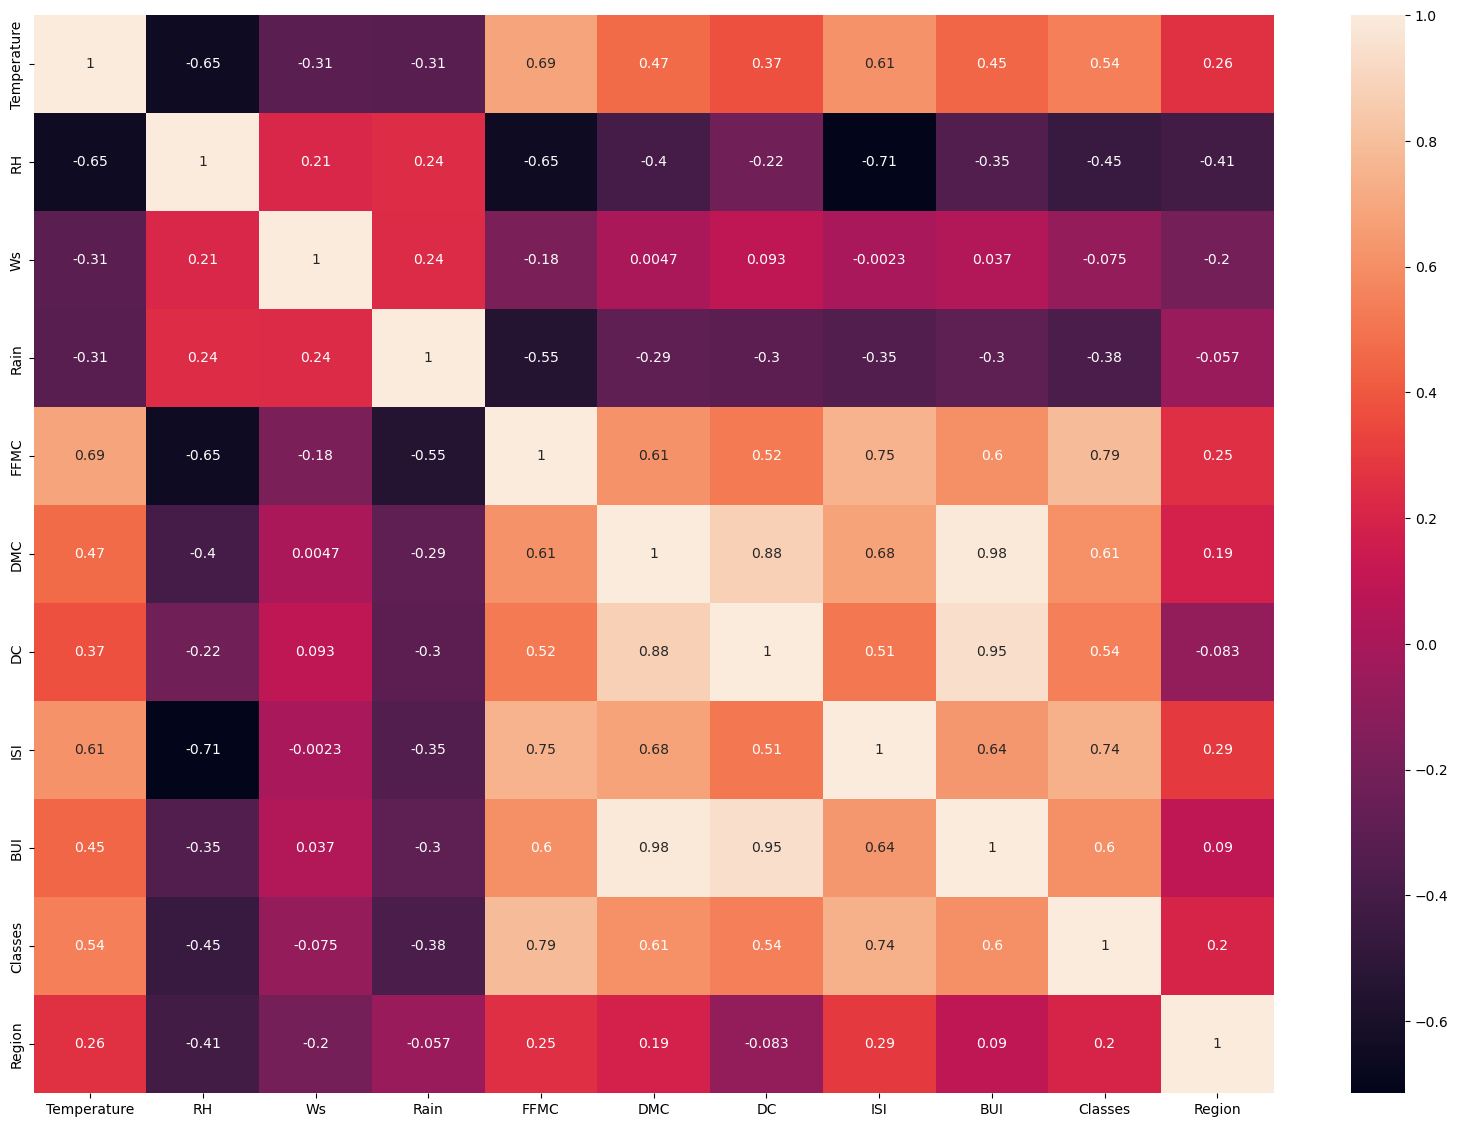

In [16]:
plt.figure(figsize=(20,14))
sns.heatmap(X_train.corr() , annot=True)

In [19]:
def correlation(data,threshold):
    col_corr = set()
    corr_matrix=data.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                col_name=corr_matrix.columns[i]
                col_corr.add(col_name)

    return col_corr

In [21]:
 dropping=correlation(X_train , 0.85)  # Threshold limit is decided by domain expert

In [25]:
X_train.drop(dropping,axis=1,inplace=True)
X_test.drop(dropping,axis=1,inplace=True)

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
24,31,64,15,0.0,86.7,14.2,5.7,1,0
6,33,54,13,0.0,88.2,9.9,6.4,1,0
152,28,58,18,2.2,63.7,3.2,1.2,0,1
232,34,58,13,0.2,79.5,18.7,2.1,0,1
238,30,65,14,0.0,85.4,16.0,4.5,1,1
175,39,64,9,1.2,73.8,11.7,1.1,0,1
215,28,75,16,0.0,82.2,4.4,3.3,1,1
150,37,36,13,0.6,86.2,17.9,4.8,1,1
9,28,79,12,0.0,73.2,9.5,1.3,0,0
113,31,50,19,0.6,77.8,10.6,2.4,0,0


# Feature Scaling

In [26]:
from sklearn.preprocessing  import StandardScaler

In [28]:
scalar = StandardScaler()
X_train_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [29]:
X_train_scaled

array([[-0.87563202,  0.21321832,  1.28577038, ..., -0.76790976,
        -1.14434427, -1.01036297],
       [ 0.22209084, -1.65484925,  0.14504117, ...,  3.10086694,
         0.8738629 ,  0.98974332],
       [ 1.5942444 , -1.25454906, -0.99568804, ..., -0.24276653,
         0.8738629 ,  0.98974332],
       ...,
       [-1.97335488,  0.947102  ,  0.52528424, ..., -1.03380506,
        -1.14434427, -1.01036297],
       [ 0.49652155, -0.18708188,  0.14504117, ...,  0.14278167,
         0.8738629 ,  0.98974332],
       [-0.60120131,  1.0138187 ,  2.04625653, ..., -0.99392076,
        -1.14434427, -1.01036297]])

# Linear Regression 

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Mean Absolute error is  0.4267520614689856
R2 score is  0.9890356825759857


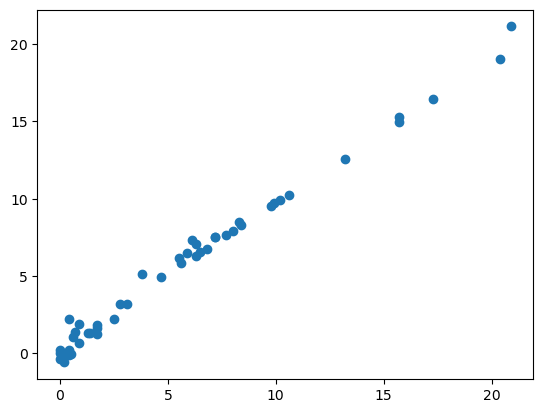

In [37]:
linreg=LinearRegression(n_jobs=-1)
linreg.fit(X_train_scaled,y_train) 
y_pred= linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

print("Mean Absolute error is " , mae)
print("R2 score is " , score)

plt.scatter(y_test,y_pred)

# Lasso Regression

In [38]:
from sklearn.linear_model import Lasso

Mean Absolute error is  0.9552746314709517
R2 score is  0.9527917018651335


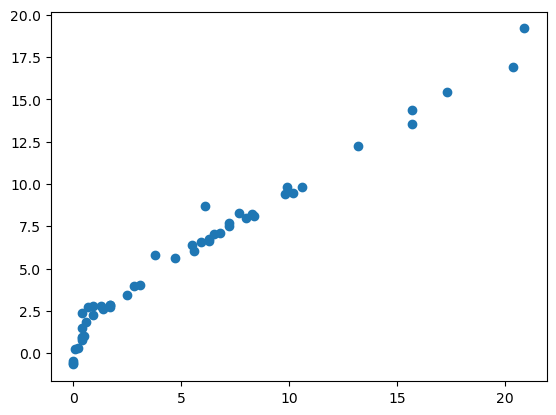

In [39]:
lasreg=Lasso()
lasreg.fit(X_train_scaled,y_train) 
y_pred= lasreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

print("Mean Absolute error is " , mae)
print("R2 score is " , score)

plt.scatter(y_test,y_pred)

In [46]:
from sklearn.linear_model import LassoCV

In [47]:
lassocv=LassoCV(cv=10,n_jobs=-1,random_state=42)
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [49]:
lassocv.alpha_

np.float64(0.03321691174892799)

Mean Absolute error is  0.42073142083457504
R2 score is  0.9882488186747139


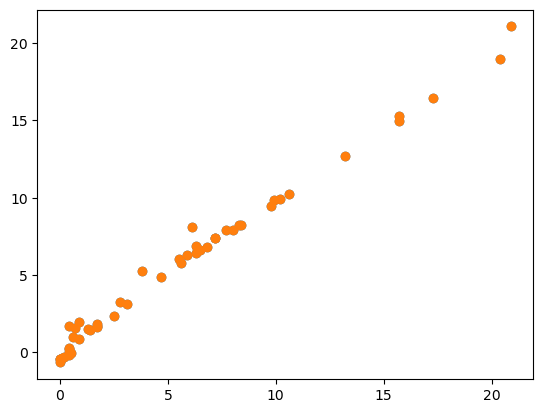

In [51]:
y_pred_lasso=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred_lasso)
mae=mean_absolute_error(y_test , y_pred_lasso)
score=r2_score(y_test , y_pred_lasso)

print("Mean Absolute error is " , mae)
print("R2 score is " , score)

plt.scatter(y_test,y_pred_lasso)

# RIDGE REGRESSION

In [40]:
from sklearn.linear_model import Ridge

Mean Absolute error is  0.4634859812027521
R2 score is  0.9845121782477889


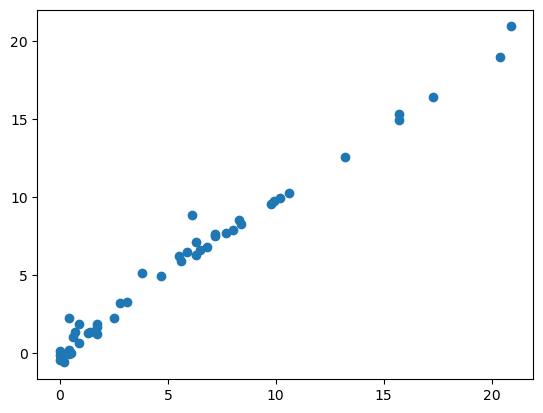

In [42]:
ridreg=Ridge()
ridreg.fit(X_train_scaled,y_train) 
y_pred= ridreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

print("Mean Absolute error is " , mae)
print("R2 score is " , score)

plt.scatter(y_test,y_pred)

# ElasticNet Regression


In [43]:
from sklearn.linear_model import ElasticNet

Mean Absolute error is  1.527915084701871
R2 score is  0.8829107841423941


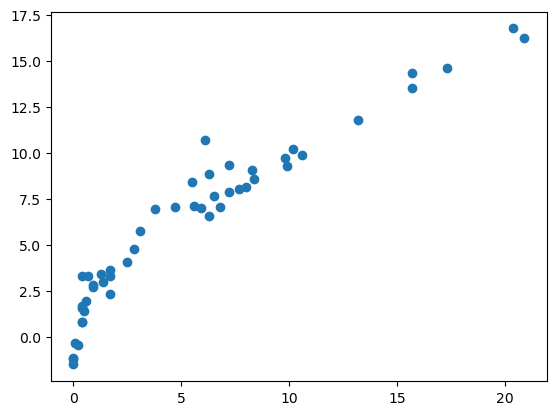

In [45]:
enreg=ElasticNet()
enreg.fit(X_train_scaled,y_train) 
y_pred= enreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test , y_pred)
score=r2_score(y_test , y_pred)

print("Mean Absolute error is " , mae)
print("R2 score is " , score)

plt.scatter(y_test,y_pred)

In [52]:
import joblib

In [54]:
joblib.dump(linreg , "Linear_regression_model.pkl")

['Linear_regression_model.pkl']

In [55]:
joblib.dump(lasreg , "Lasso_regression_model.pkl")


['Lasso_regression_model.pkl']

In [56]:
joblib.dump(ridreg , "Ridge_regression_model.pkl")

['Ridge_regression_model.pkl']

In [57]:
joblib.dump(enreg , "ElasticNet_regression_model.pkl")

['ElasticNet_regression_model.pkl']